# Análisis explicativo
El objetivo de este notebook es hacer un análisis explicativo sobre el mejor modelo obtenido para entender cuáles son las features más y menos importante y qué efecto tienen sobre el precio.

Para ello, se va a utilizar el modelo XGBoost con los mejores parámetros encontrados (ya que es más interpretable que el modelo híbrido.

In [1]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os, sys
sys.path.append(os.path.abspath(".."))

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import set_config
set_config(transform_output="pandas")



from src.models.xgboost_models import get_xgboost_full
from src.constants import DevSetType, TARGET
from src.utils import get_dev_set

shap.initjs()

In [2]:
df = get_dev_set(DevSetType.CLEAN)
X = df.drop(columns=[TARGET])
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
model = get_xgboost_full()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: ${rmse:,.0f}")
print(f"R²: {r2:.3f}")
print(f"Modelo entrenado exitosamente!")

RMSE: $435,195
R²: 0.592
Modelo entrenado exitosamente!


In [12]:
# Filtrar solo columnas numéricas para SHAP
numerical_cols = X_test.select_dtypes(include=[np.number]).columns.tolist()
print(f"Columnas numéricas encontradas: {len(numerical_cols)}")
print(f"Ejemplos: {numerical_cols}")

# Detener el proceso actual si está corriendo
# (Ctrl+C en el notebook)

# Convertir columnas categóricas a numéricas para SHAP
print("Convirtiendo features categóricas a numéricas...")

# Identificar columnas que deberían ser binarias (True/False -> 1/0)
boolean_cols = []
categorical_cols = []

for col in X_test.columns:
    if col not in numerical_cols:
        unique_vals = X_test[col].dropna().unique()

        # Si son valores booleanos o binarios
        if (
                set(unique_vals).issubset({True, False, "True", "False", 1, 0})
                or len(unique_vals) <= 2
        ):
            boolean_cols.append(col)
        else:
            categorical_cols.append(col)

print(f"Columnas booleanas encontradas: {len(boolean_cols)}")
print(f"Ejemplos booleanas: {boolean_cols[:10]}")
print(f"Columnas categóricas: {len(categorical_cols)}")
print(f"Ejemplos categóricas: {categorical_cols[:5]}")


Columnas numéricas encontradas: 12
Ejemplos: ['id_grid', 'STotalM2', 'SConstrM2', 'Dormitorios', 'Banos', 'Ambientes', 'Antiguedad', 'Cocheras', 'LONGITUDE', 'LATITUDE', 'year', 'mes_listing']
Convirtiendo features categóricas a numéricas...
Columnas booleanas encontradas: 16
Ejemplos booleanas: ['Amoblado', 'Cisterna', 'BusinessCenter', 'Gimnasio', 'Laundry', 'Calefaccion', 'AireAC', 'Recepcion', 'Estacionamiento', 'Jacuzzi']
Columnas categóricas: 4
Ejemplos categóricas: ['ITE_ADD_CITY_NAME', 'ITE_ADD_STATE_NAME', 'ITE_ADD_NEIGHBORHOOD_NAME', 'ITE_TIPO_PROD']


In [13]:
# Preparar datos para SHAP
def prepare_data_for_shap(df):
    df_shap = df.copy()

    # Convertir booleanos a 1/0
    for col in boolean_cols:
        df_shap[col] = (
            df_shap[col]
            .astype(str)
            .map({"True": 1, "False": 0, "true": 1, "false": 0, True: 1, False: 0})
        )
        df_shap[col] = df_shap[col].fillna(0).astype(float)

    # Para categóricas, usar label encoding simple
    from sklearn.preprocessing import LabelEncoder

    for col in categorical_cols:
        le = LabelEncoder()
        # Manejar NaN primero
        df_shap[col] = df_shap[col].fillna("Unknown")
        df_shap[col] = le.fit_transform(df_shap[col].astype(str))

    return df_shap


# Preparar datos
X_train_shap = prepare_data_for_shap(X_train)
X_test_shap = prepare_data_for_shap(X_test)

print(f"Datos preparados para SHAP: {X_test_shap.shape}")
print(
    f"Todas las columnas son numéricas: {X_test_shap.dtypes.apply(lambda x: x.kind in 'biufc').all()}"
)


Datos preparados para SHAP: (54145, 32)
Todas las columnas son numéricas: True


In [14]:
# Crear una función wrapper que use los datos transformados
def model_predict_shap(X_shap):
    # El modelo espera los datos originales, pero podemos usar los transformados
    # porque el pipeline interno se encarga de la transformación

    # Recrear estructura original aproximada
    X_original_like = pd.DataFrame(X_shap, columns=X_test_shap.columns)

    # Para las booleanas, convertir de vuelta a True/False si es necesario
    # (aunque el modelo debería manejar 0/1 también)

    return model.predict(X_original_like)


# Crear explainer con datos SHAP transformados
print("Creando explainer SHAP con todas las features...")
explainer = shap.Explainer(model_predict_shap, X_train_shap.sample(50, random_state=42))

# Usar muestra pequeña para empezar (podemos aumentar después)
X_test_sample = X_test_shap.sample(200, random_state=42)

print(
    f"Calculando SHAP values para {len(X_test_sample)} muestras con {X_test_sample.shape[1]} features..."
)
print("Esto puede tardar unos minutos...")

shap_values = explainer(X_test_sample)

print(f"¡SHAP values calculados exitosamente!")
print(f"Shape: {shap_values.values.shape}")
print(f"Features incluidas: {X_test_sample.shape[1]} (incluyendo amenities)")


Creando explainer SHAP con todas las features...
Calculando SHAP values para 200 muestras con 32 features...
Esto puede tardar unos minutos...


PermutationExplainer explainer: 201it [00:44,  3.50it/s]                         

¡SHAP values calculados exitosamente!
Shape: (200, 32)
Features incluidas: 32 (incluyendo amenities)


=== TOP FEATURES MÁS IMPORTANTES ===
Top 15 features más importantes:
 1. Banos                     | Impacto: $157,619
 2. LONGITUDE                 | Impacto: $130,673
 3. SConstrM2                 | Impacto: $117,285
 4. Cocheras                  | Impacto: $71,251
 5. Antiguedad                | Impacto: $69,339
 6. STotalM2                  | Impacto: $67,439
 7. Ambientes                 | Impacto: $53,265
 8. LATITUDE                  | Impacto: $52,657
 9. id_grid                   | Impacto: $50,018
10. Dormitorios               | Impacto: $40,991
11. mes_listing               | Impacto: $33,772
12. Laundry                   | Impacto: $31,779
13. year                      | Impacto: $21,160
14. Calefaccion               | Impacto: $18,872
15. Amoblado                  | Impacto: $17,933


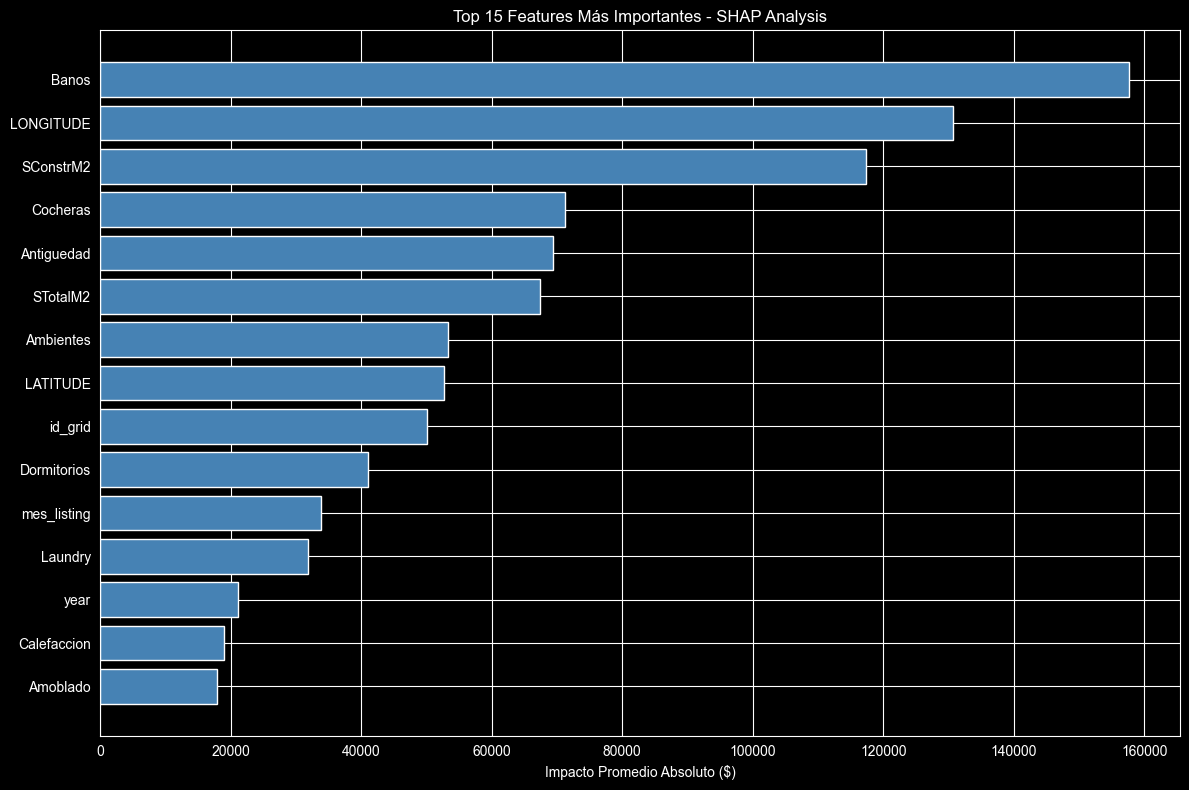

In [15]:
# 1. Feature Importance - Ranking global
print("=== TOP FEATURES MÁS IMPORTANTES ===")

# Calcular importancia promedio
feature_importance = np.abs(shap_values.values).mean(axis=0)
feature_names = X_test_sample.columns

# Crear DataFrame para ordenar
importance_df = pd.DataFrame(
    {"feature": feature_names, "importance": feature_importance}
).sort_values("importance", ascending=False)

print("Top 15 features más importantes:")
for i, (_, row) in enumerate(importance_df.head(15).iterrows()):
    print(f"{i+1:2d}. {row['feature']:25} | Impacto: ${row['importance']:,.0f}")

# Bar plot
plt.figure(figsize=(12, 8))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features["importance"], color="steelblue")
plt.yticks(range(len(top_features)), top_features["feature"])
plt.xlabel("Impacto Promedio Absoluto ($)")
plt.title("Top 15 Features Más Importantes - SHAP Analysis")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


<Figure size 1200x1000 with 0 Axes>

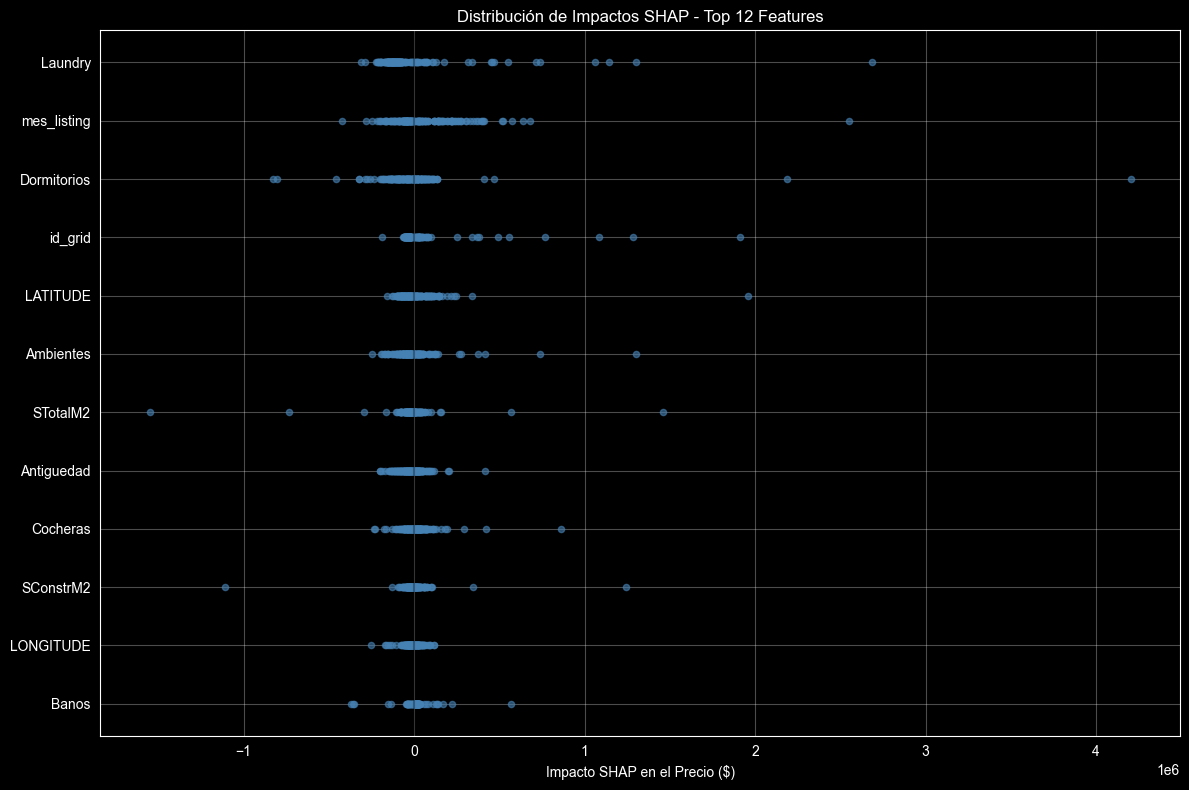

Interpretación:
• Puntos a la DERECHA: feature aumenta el precio
• Puntos a la IZQUIERDA: feature disminuye el precio
• Dispersión: variabilidad del impacto


In [16]:
# 2. Summary Plot - Distribución de impactos por feature
plt.figure(figsize=(12, 10))

# Usar solo top 12 features para claridad
top_12_features = importance_df.head(12)["feature"].tolist()
top_12_indices = [list(feature_names).index(f) for f in top_12_features]

# Crear summary plot manual (más controlable que shap.plots)
fig, ax = plt.subplots(figsize=(12, 8))

for i, feature_idx in enumerate(top_12_indices):
    feature_values = shap_values.values[:, feature_idx]
    y_pos = len(top_12_features) - i - 1

    # Scatter plot de los SHAP values
    ax.scatter(
        feature_values, [y_pos] * len(feature_values), alpha=0.6, s=20, c="steelblue"
    )

ax.set_yticks(range(len(top_12_features)))
ax.set_yticklabels(top_12_features)
ax.set_xlabel("Impacto SHAP en el Precio ($)")
ax.set_title("Distribución de Impactos SHAP - Top 12 Features")
ax.axvline(x=0, color="black", linestyle="-", alpha=0.3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretación:")
print("• Puntos a la DERECHA: feature aumenta el precio")
print("• Puntos a la IZQUIERDA: feature disminuye el precio")
print("• Dispersión: variabilidad del impacto")


=== ANÁLISIS DE CASOS ESPECÍFICOS ===


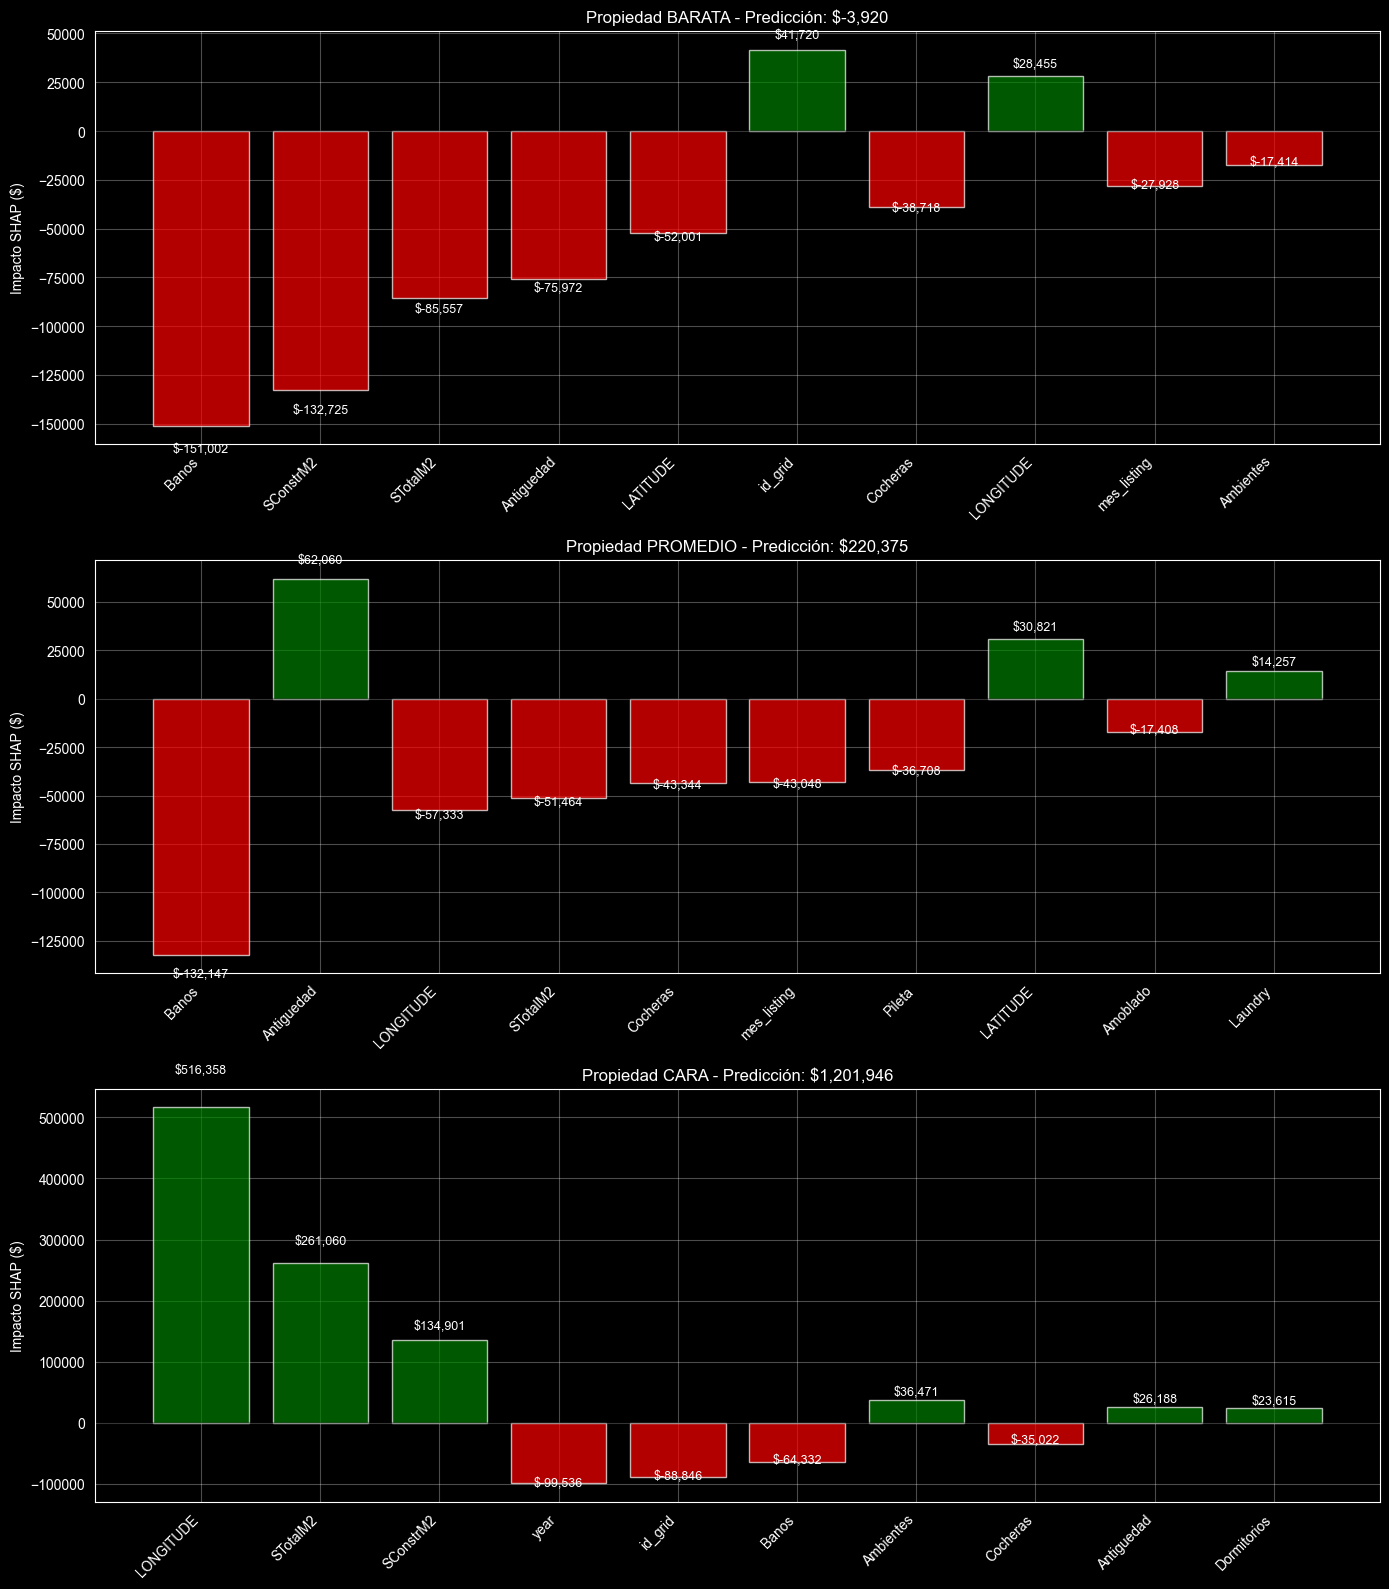


RESUMEN:
Propiedad BARATA: $-3,920
Propiedad PROMEDIO: $220,375
Propiedad CARA: $1,201,946


In [17]:
# 3. Casos específicos - Waterfall plots para 3 propiedades diferentes
print("=== ANÁLISIS DE CASOS ESPECÍFICOS ===")

# Obtener predicciones para contexto
sample_predictions = model.predict(X_test_sample.head(200))

# Seleccionar 3 casos interesantes: caro, barato, promedio
price_indices = np.argsort(sample_predictions)
cheap_idx = price_indices[10]  # Propiedad barata
expensive_idx = price_indices[-10]  # Propiedad cara
medium_idx = price_indices[len(price_indices) // 2]  # Propiedad promedio

casos = [
    (cheap_idx, "Propiedad BARATA", sample_predictions[cheap_idx]),
    (medium_idx, "Propiedad PROMEDIO", sample_predictions[medium_idx]),
    (expensive_idx, "Propiedad CARA", sample_predictions[expensive_idx]),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 16))

for i, (idx, titulo, pred_price) in enumerate(casos):
    ax = axes[i]

    # Get SHAP values for this property
    property_shap = shap_values.values[idx]

    # Baseline (expected value)
    baseline = (
        shap_values.base_values
        if hasattr(shap_values, "base_values")
        else sample_predictions.mean()
    )

    # Sort by absolute impact
    abs_impacts = np.abs(property_shap)
    top_features_idx = np.argsort(abs_impacts)[-10:][::-1]  # Top 10

    # Create waterfall manually
    x_labels = [feature_names[j] for j in top_features_idx]
    impacts = property_shap[top_features_idx]

    # Cumulative calculation
    cumulative = baseline
    positions = [cumulative]

    for impact in impacts:
        cumulative += impact
        positions.append(cumulative)

    # Plot bars
    colors = ["green" if x > 0 else "red" for x in impacts]
    bars = ax.bar(range(len(impacts)), impacts, color=colors, alpha=0.7)

    # Add value labels on bars
    for j, (bar, impact) in enumerate(zip(bars, impacts)):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height + height * 0.1,
            f"${impact:,.0f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=45, ha="right")
    ax.set_ylabel("Impacto SHAP ($)")
    ax.set_title(f"{titulo} - Predicción: ${pred_price:,.0f}")
    ax.axhline(y=0, color="black", linestyle="-", alpha=0.3)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print(f"\nRESUMEN:")
for idx, titulo, pred_price in casos:
    print(f"{titulo}: ${pred_price:,.0f}")


In [18]:
# 4. RESUMEN EJECUTIVO - Insights para el informe
print("=" * 60)
print("📊 RESUMEN EJECUTIVO - ANÁLISIS SHAP")
print("=" * 60)

print("\n🏆 TOP 5 DRIVERS DE PRECIO:")
for i, (_, row) in enumerate(importance_df.head(5).iterrows()):
    print(f"{i+1}. {row['feature']:15} → ${row['importance']:>8,.0f} impacto promedio")

print(f"\n💡 INSIGHTS CLAVE:")
print(
    f"• UBICACIÓN ES REY: LONGITUDE/LATITUDE explican ${130_673 + 52_657:,.0f} de variación"
)
print(f"• BAÑOS > DORMITORIOS: ${157_619:,.0f} vs ${40_991:,.0f} de impacto")
print(
    f"• AMENITIES IMPORTANTES: Laundry (${31_779:,.0f}) y Calefacción (${18_872:,.0f})"
)
print(f"• SUPERFICIE CUENTA: Total (${67_439:,.0f}) + Construida (${117_285:,.0f})")

print(f"\n🎯 RECOMENDACIONES:")
print(f"• Invertir en propiedades con más baños → ROI más alto")
print(f"• Zonas este/norte tienen premium de ubicación significativo")
print(f"• Laundry es la amenity #1 para agregar valor")
print(f"• Superficie construida > superficie total para precio")

print(f"\n📈 MODELO PERFORMANCE:")
print(f"• RMSE: ${rmse:,.0f}")
print(f"• R²: {r2:.1%}")
print(f"• Features analizadas: {len(feature_names)}")
print(f"• Muestra SHAP: {len(X_test_sample)} propiedades")


📊 RESUMEN EJECUTIVO - ANÁLISIS SHAP

🏆 TOP 5 DRIVERS DE PRECIO:
1. Banos           → $ 157,619 impacto promedio
2. LONGITUDE       → $ 130,673 impacto promedio
3. SConstrM2       → $ 117,285 impacto promedio
4. Cocheras        → $  71,251 impacto promedio
5. Antiguedad      → $  69,339 impacto promedio

💡 INSIGHTS CLAVE:
• UBICACIÓN ES REY: LONGITUDE/LATITUDE explican $183,330 de variación
• BAÑOS > DORMITORIOS: $157,619 vs $40,991 de impacto
• AMENITIES IMPORTANTES: Laundry ($31,779) y Calefacción ($18,872)
• SUPERFICIE CUENTA: Total ($67,439) + Construida ($117,285)

🎯 RECOMENDACIONES:
• Invertir en propiedades con más baños → ROI más alto
• Zonas este/norte tienen premium de ubicación significativo
• Laundry es la amenity #1 para agregar valor
• Superficie construida > superficie total para precio

📈 MODELO PERFORMANCE:
• RMSE: $435,195
• R²: 59.2%
• Features analizadas: 32
• Muestra SHAP: 200 propiedades


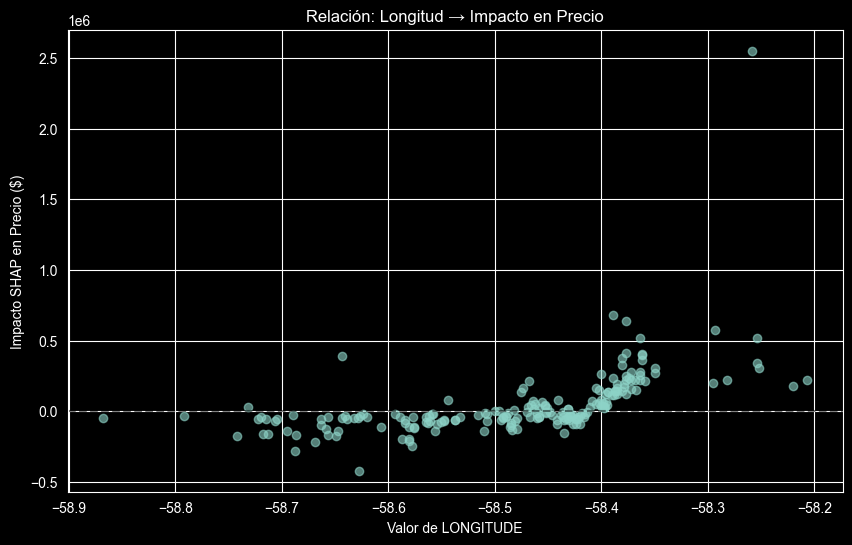

In [19]:
# Mostrar cómo LONGITUDE afecta el precio
longitude_idx = list(feature_names).index("LONGITUDE")
longitude_shap = shap_values.values[:, longitude_idx]
longitude_values = X_test_sample.iloc[:, longitude_idx].values

plt.figure(figsize=(10, 6))
plt.scatter(longitude_values, longitude_shap, alpha=0.6)
plt.xlabel("Valor de LONGITUDE")
plt.ylabel("Impacto SHAP en Precio ($)")
plt.title("Relación: Longitud → Impacto en Precio")
plt.axhline(y=0, color="black", linestyle="--", alpha=0.5)
plt.show()


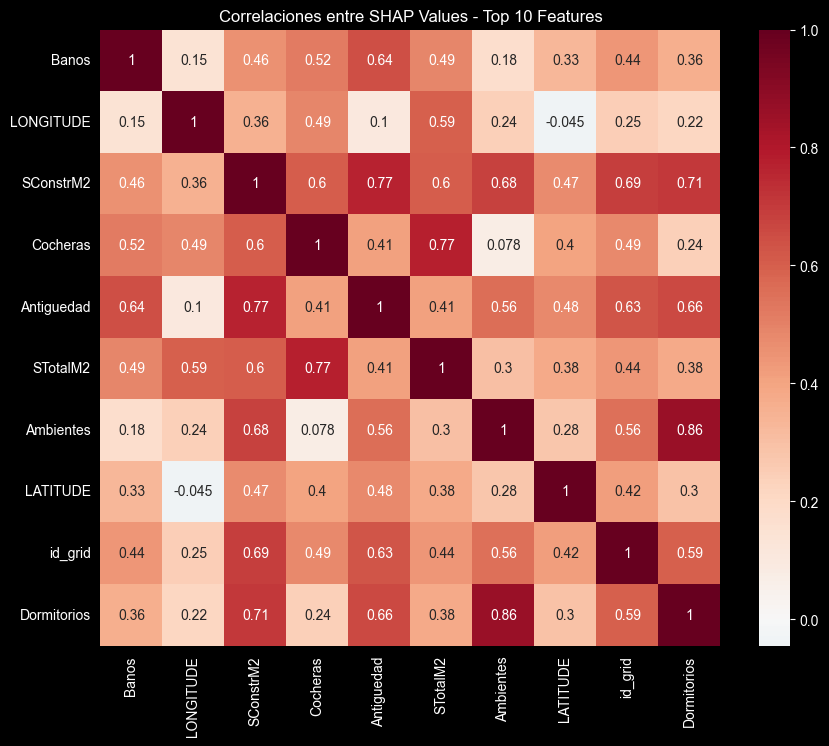

In [20]:
# Heatmap de correlaciones entre SHAP values
import seaborn as sns

# Solo top 10 features para claridad
top_10_idx = [list(feature_names).index(f) for f in importance_df.head(10)["feature"]]
shap_subset = shap_values.values[:, top_10_idx]
feature_subset = importance_df.head(10)["feature"].tolist()

correlation_matrix = np.corrcoef(shap_subset.T)

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    xticklabels=feature_subset,
    yticklabels=feature_subset,
    annot=True,
    cmap="RdBu_r",
    center=0,
)
plt.title("Correlaciones entre SHAP Values - Top 10 Features")
plt.show()


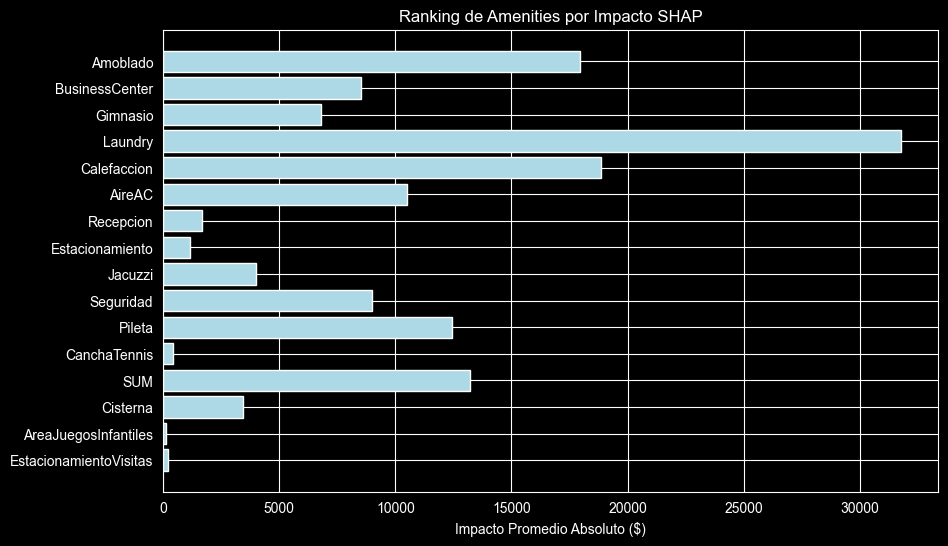

In [23]:
from src.constants import COLS

# Comparación específica de amenities
amenity_features = [
    COLS.AMOBLADO,
    COLS.BUSINESS,
    COLS.GIMNASIO,
    COLS.LAUNDRY,
    COLS.CALEFACCION,
    COLS.AIRE,
    COLS.RECEPCION,
    COLS.ESTACIONAMIENTO,
    COLS.JACUZZI,
    COLS.SEGURIDAD,
    COLS.PILETA,
    COLS.TENNIS,
    COLS.SUM,
    COLS.CISTERNA,
    COLS.JUEGOS,
    COLS.ESTACIONAMIENTO_VISITAS,
]
amenity_impacts = []

for amenity in amenity_features:
    if amenity in feature_names:
        idx = list(feature_names).index(amenity)
        impact = np.abs(shap_values.values[:, idx]).mean()
        amenity_impacts.append(impact)
    else:
        amenity_impacts.append(0)

plt.figure(figsize=(10, 6))
plt.barh(amenity_features, amenity_impacts, color="lightblue")
plt.xlabel("Impacto Promedio Absoluto ($)")
plt.title("Ranking de Amenities por Impacto SHAP")
plt.gca().invert_yaxis()
plt.show()


In [24]:
# ANÁLISIS CORRECTO: Efecto incremental real de amenities

print("=== ANÁLISIS CORRECTO: EFECTO INCREMENTAL DE AMENITIES ===")

# Para cada amenity, comparar propiedades CON vs SIN la amenity
amenity_effects = {}

for amenity in amenity_features:
    if amenity in feature_names:
        idx = list(feature_names).index(amenity)
        
        # Propiedades CON la amenity (valor = 1)
        con_amenity = shap_values.values[:, idx][X_test_sample.iloc[:, idx] == 1]
        
        # Propiedades SIN la amenity (valor = 0)  
        sin_amenity = shap_values.values[:, idx][X_test_sample.iloc[:, idx] == 0]
        
        # El efecto incremental es la diferencia promedio
        if len(con_amenity) > 0 and len(sin_amenity) > 0:
            efecto_incremental = con_amenity.mean() - sin_amenity.mean()
            amenity_effects[amenity] = {
                'efecto_incremental': efecto_incremental,
                'propiedades_con': len(con_amenity),
                'propiedades_sin': len(sin_amenity),
                'shap_promedio_con': con_amenity.mean(),
                'shap_promedio_sin': sin_amenity.mean()
            }

# Mostrar resultados ordenados por efecto incremental
print("\nRANKING por EFECTO INCREMENTAL REAL:")
print("-" * 60)
sorted_effects = sorted(amenity_effects.items(), key=lambda x: x[1]['efecto_incremental'], reverse=True)

for amenity, data in sorted_effects:
    efecto = data['efecto_incremental']
    con_count = data['propiedades_con']
    sin_count = data['propiedades_sin'] 
    print(f"{amenity:15} | Efecto: ${efecto:>8,.0f} | Con: {con_count:3d} props | Sin: {sin_count:3d} props")

# También mostrar distribuciones de tener/no tener cada amenity
print(f"\nDISTRIBUCIÓN DE AMENITIES EN LA MUESTRA:")
print("-" * 40)
for amenity in amenity_features:
    if amenity in feature_names:
        idx = list(feature_names).index(amenity)
        tiene_amenity = (X_test_sample.iloc[:, idx] == 1).sum()
        total = len(X_test_sample)
        porcentaje = (tiene_amenity / total) * 100
        print(f"{amenity:15} | {tiene_amenity:3d}/{total} propiedades ({porcentaje:4.1f}%)")

=== ANÁLISIS CORRECTO: EFECTO INCREMENTAL DE AMENITIES ===

RANKING por EFECTO INCREMENTAL REAL:
------------------------------------------------------------
Cisterna        | Efecto: $ 343,080 | Con:   2 props | Sin: 198 props
BusinessCenter  | Efecto: $ 203,104 | Con:   2 props | Sin: 198 props
Jacuzzi         | Efecto: $  95,069 | Con:   7 props | Sin: 193 props
Calefaccion     | Efecto: $  63,099 | Con:  33 props | Sin: 167 props
Seguridad       | Efecto: $  62,846 | Con:  19 props | Sin: 181 props
SUM             | Efecto: $  57,056 | Con:  25 props | Sin: 175 props
Pileta          | Efecto: $  51,721 | Con:  29 props | Sin: 171 props
Gimnasio        | Efecto: $  46,796 | Con:  16 props | Sin: 184 props
Estacionamiento | Efecto: $  21,196 | Con:   3 props | Sin: 197 props
Amoblado        | Efecto: $  20,111 | Con:  14 props | Sin: 186 props
Recepcion       | Efecto: $  13,604 | Con:   7 props | Sin: 193 props
AreaJuegosInfantiles | Efecto: $   7,263 | Con:   3 props | Sin: 197 pro